# Compare Technology-Specific Mean Expression Vectors

This notebook loads and compares the technology-specific mean expression vectors from the Nicheformer model_means directory.

**Files analyzed:**
- `cosmx_mean_script.npy` — CosMx spatial
- `xenium_mean_script.npy` — Xenium spatial
- `merfish_mean_script.npy` — MERFISH spatial
- `dissociated_mean_script.npy` — scRNA-seq dissociated
- `iss_mean_script.npy` — In Situ Sequencing

All vectors are 20,310-dimensional, matching the 20,310 genes in `model.h5ad`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scanpy as sc
from os.path import join

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

BASE_PATH = '/root/code/25-12/nicheformer/data/model_means'

In [2]:
# Load model to get gene names
model = sc.read_h5ad(f'{BASE_PATH}/model.h5ad')
gene_names = list(model.var_names)
print(f'Model: {model.n_obs} cell x {model.n_vars} genes')
print(f'First 5 genes: {gene_names[:5]}')

Model: 1 cell x 20310 genes
First 5 genes: ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']


In [3]:
# Load all technology means
technologies = {
    'CosMx': 'cosmx_mean_script.npy',
    'Xenium': 'xenium_mean_script.npy',
    'MERFISH': 'merfish_mean_script.npy',
    'Dissociated': 'dissociated_mean_script.npy',
    'ISS': 'iss_mean_script.npy',
}

means = {}
for name, fname in technologies.items():
    arr = np.load(join(BASE_PATH, fname))
    means[name] = arr
    print(f'{name:15s} | shape: {str(arr.shape):12s} | dtype: {arr.dtype} | '
          f'NaNs: {np.isnan(arr).sum():5d} | Infs: {np.isinf(arr).sum()}')

# Build a DataFrame for easy analysis
df = pd.DataFrame(means, index=gene_names)
print(f'\nDataFrame shape: {df.shape}')
df.head()

CosMx           | shape: (20310,)     | dtype: float64 | NaNs: 18453 | Infs: 0
Xenium          | shape: (20310,)     | dtype: float64 | NaNs: 18575 | Infs: 0
MERFISH         | shape: (20310,)     | dtype: float64 | NaNs: 14505 | Infs: 0
Dissociated     | shape: (20310,)     | dtype: float64 | NaNs:    60 | Infs: 0
ISS             | shape: (20310,)     | dtype: float64 | NaNs: 19776 | Infs: 0

DataFrame shape: (20310, 5)


,CosMx,Xenium,MERFISH,Dissociated,ISS
ENSG00000000003,NaN,NaN,NaN,2.575343,NaN
ENSG00000000005,NaN,NaN,NaN,1.625292,NaN
ENSG00000000419,NaN,NaN,NaN,2.066936,NaN
ENSG00000000457,NaN,NaN,NaN,2.252061,NaN
ENSG00000000460,NaN,NaN,53.10327,3.547008,NaN


## 1. Gene Coverage (Non-NaN genes per technology)

How many genes are detected (non-NaN) in each technology?

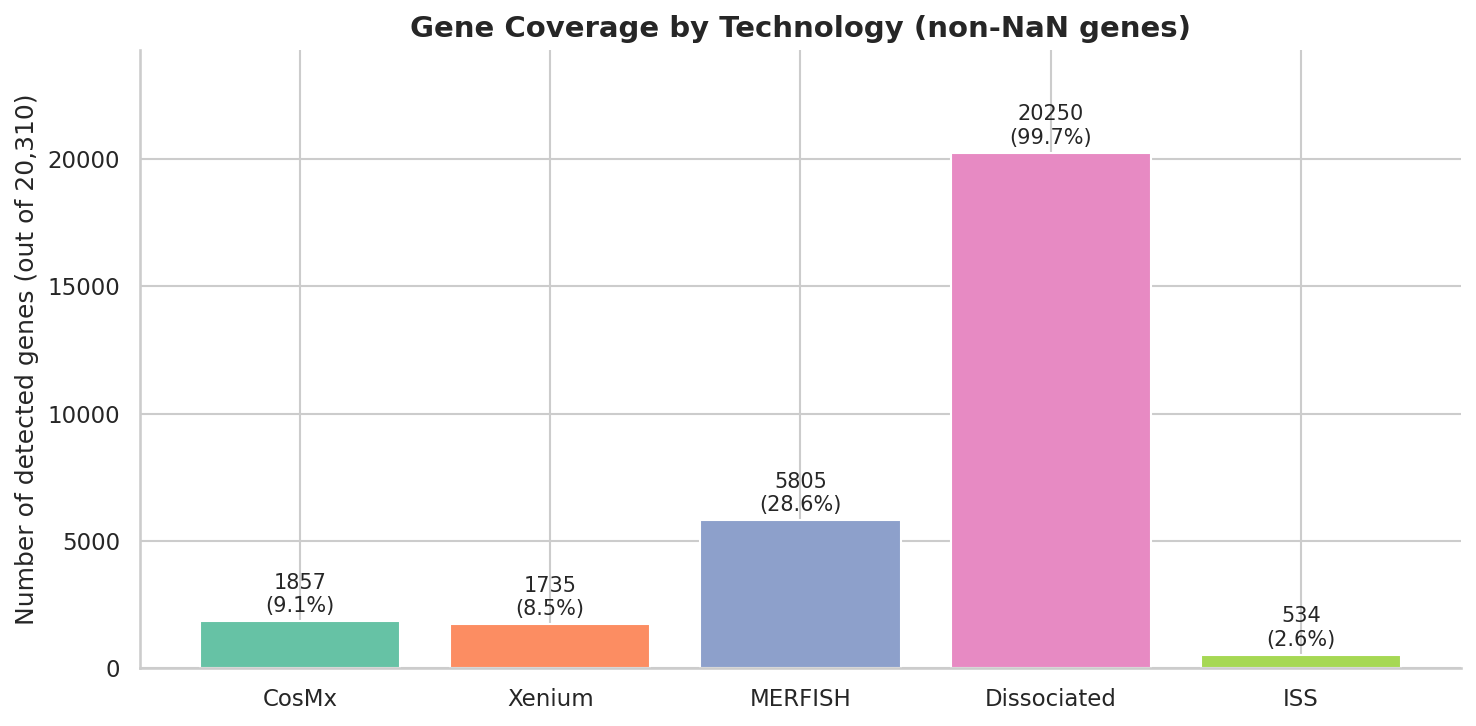

In [4]:
coverage = df.notna().sum()
coverage_pct = (coverage / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(coverage.index, coverage.values, color=sns.color_palette('Set2', n_colors=len(coverage)))

# Add value labels on bars
for bar, pct in zip(bars, coverage_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height())}\n({pct}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Gene Coverage by Technology (non-NaN genes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of detected genes (out of 20,310)')
ax.set_ylim(0, coverage.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

## 2. Distribution of Mean Expression Values

After processing (nan_to_num → round → replace zeros with 1), what do the distributions look like?

In [5]:
# Process each mean vector the same way as in the tokenization notebook
def process_mean(arr):
    arr = np.nan_to_num(arr)
    rounded = np.where((arr % 1) >= 0.5, np.ceil(arr), np.floor(arr))
    return np.where(arr == 0, 1, rounded)

processed = {name: process_mean(arr) for name, arr in means.items()}
df_processed = pd.DataFrame(processed, index=gene_names)

print('Processed mean stats:')
df_processed.describe().round(2)

Processed mean stats:


,CosMx,Xenium,MERFISH,Dissociated,ISS
count,20310.00,20310.00,20310.00,20310.00,20310.00
mean,4.41,15.11,19.06,3.49,22.01
std,16.08,53.30,70.82,8.71,140.86
min,1.00,1.00,-2370.00,0.00,1.00
25%,1.00,1.00,1.00,2.00,1.00
50%,1.00,1.00,1.00,2.00,1.00
75%,1.00,1.00,20.00,3.00,1.00
max,567.00,975.00,3834.00,555.00,3023.00


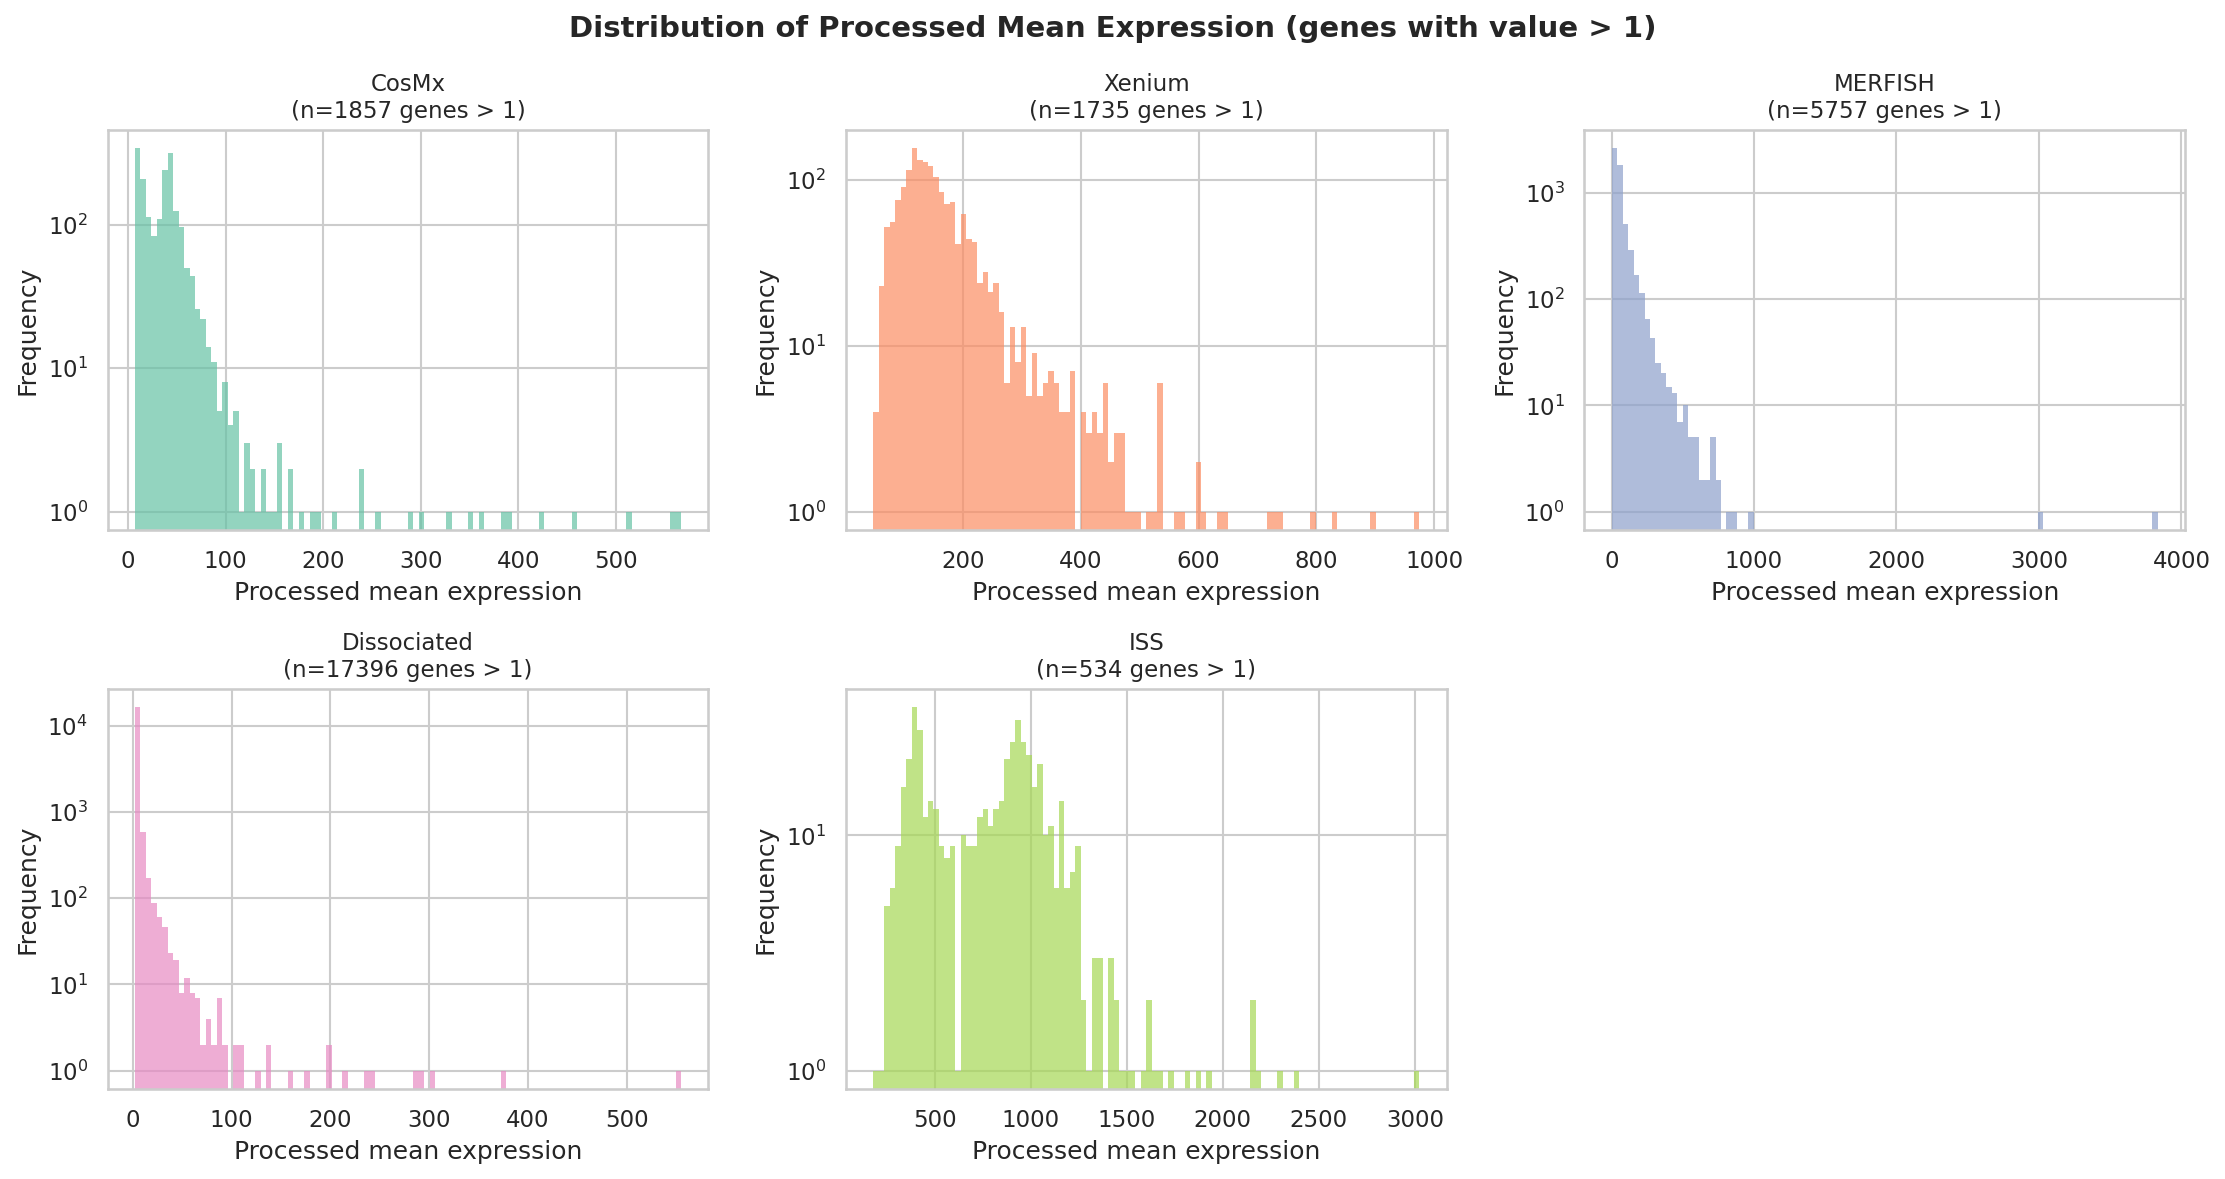

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, arr) in enumerate(processed.items()):
    ax = axes[i]
    # Filter out zeros (which are NaN-replaced) for better visualization
    non_zero = arr[arr > 1]
    ax.hist(non_zero, bins=100, color=sns.color_palette('Set2')[i], alpha=0.7, edgecolor='none')
    ax.set_title(f'{name}\n(n={len(non_zero)} genes > 1)', fontsize=11)
    ax.set_xlabel('Processed mean expression')
    ax.set_ylabel('Frequency')
    ax.set_yscale('log')

# Hide the 6th subplot
axes[5].set_visible(False)
plt.suptitle('Distribution of Processed Mean Expression (genes with value > 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pairwise Correlation Between Technologies

How similar are the mean expression profiles across technologies? We compute Pearson correlation on the overlap of genes detected in both technologies.

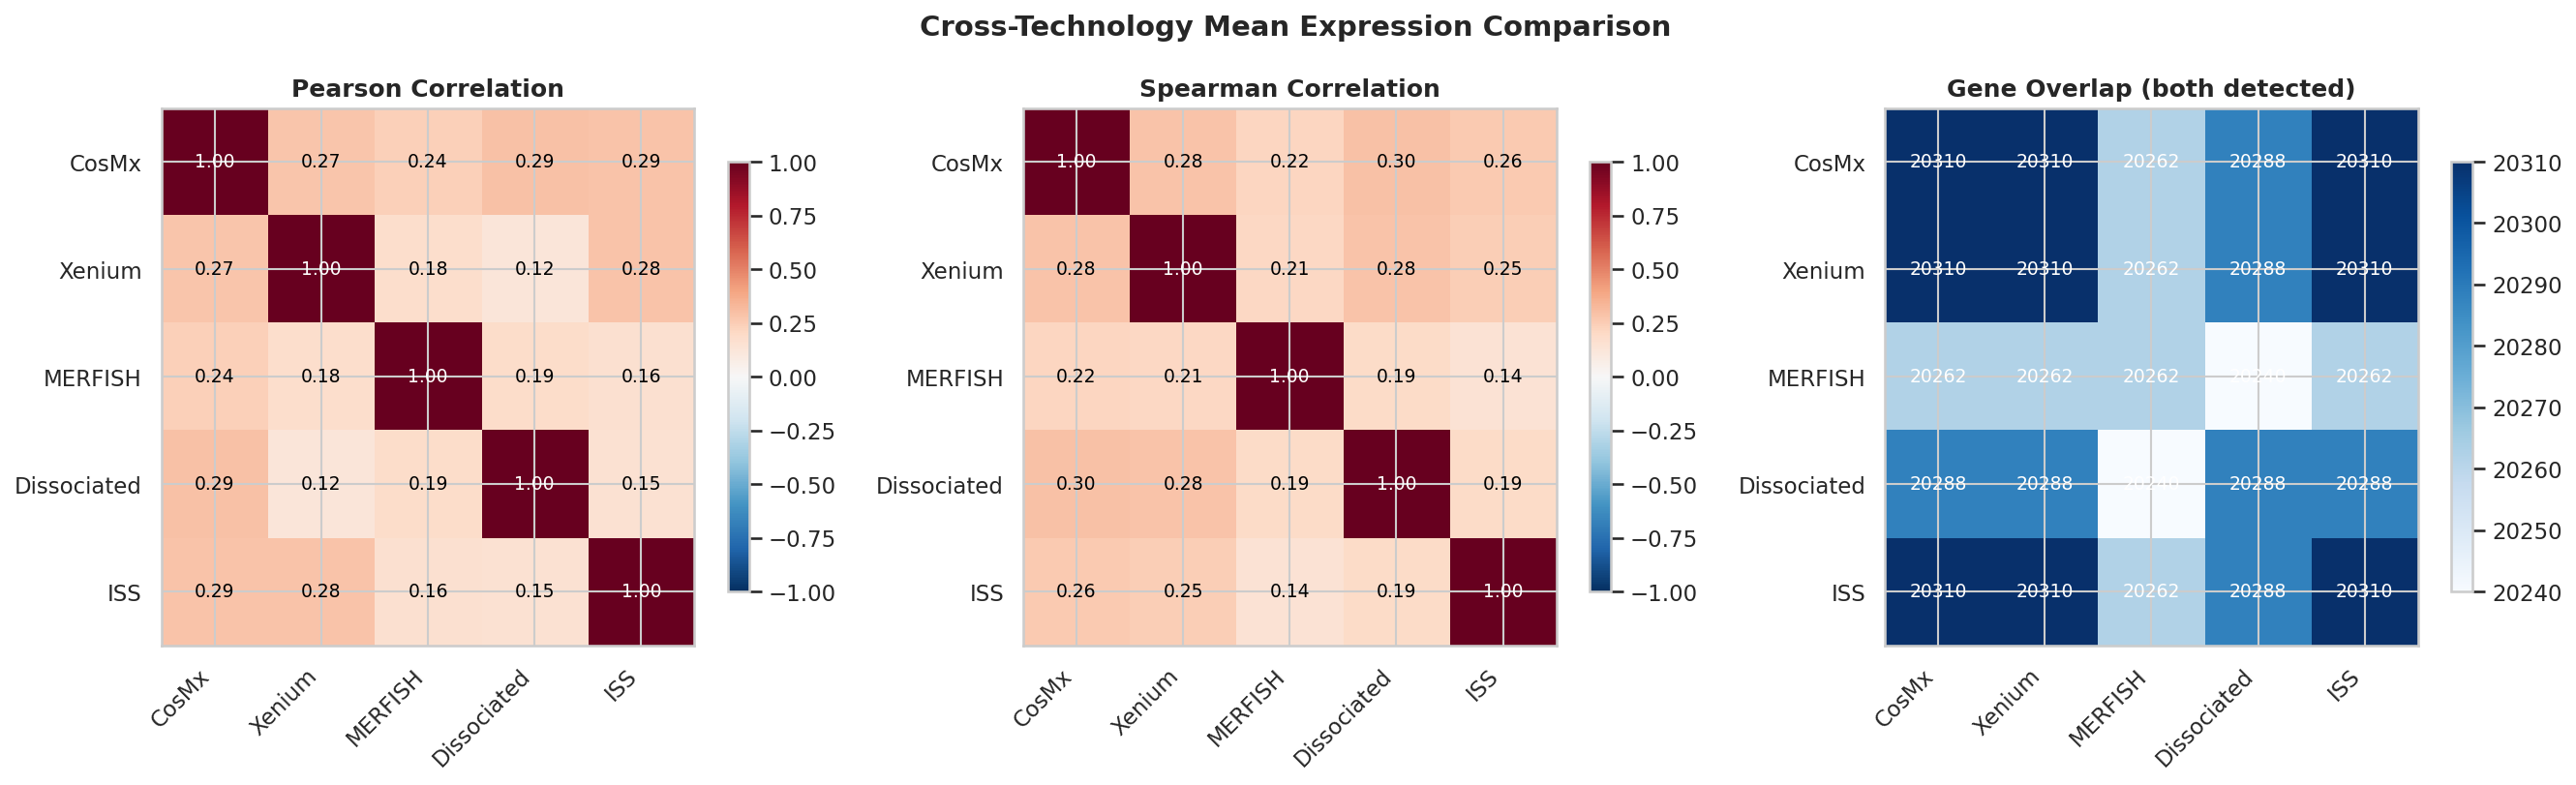

In [7]:
from scipy.stats import pearsonr, spearmanr

tech_names = list(processed.keys())
n = len(tech_names)
pearson_mat = np.zeros((n, n))
spearman_mat = np.zeros((n, n))
overlap_mat = np.zeros((n, n), dtype=int)

for i, t1 in enumerate(tech_names):
    for j, t2 in enumerate(tech_names):
        # Only consider genes where both have non-NaN (after nan_to_num, > 0)
        mask = (df_processed[t1] > 0) & (df_processed[t2] > 0)
        overlap = mask.sum()
        overlap_mat[i, j] = overlap
        if overlap > 1:
            pearson_mat[i, j], _ = pearsonr(df_processed[t1][mask], df_processed[t2][mask])
            spearman_mat[i, j], _ = spearmanr(df_processed[t1][mask], df_processed[t2][mask])
        else:
            pearson_mat[i, j] = np.nan
            spearman_mat[i, j] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Pearson correlation
ax = axes[0]
im = ax.imshow(pearson_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(n):
    for j in range(n):
        val = pearson_mat[i, j]
        text = f'{val:.2f}' if not np.isnan(val) else 'N/A'
        ax.text(j, i, text, ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.5 else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tech_names, rotation=45, ha='right')
ax.set_yticklabels(tech_names)
ax.set_title('Pearson Correlation', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Spearman correlation
ax = axes[1]
im = ax.imshow(spearman_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(n):
    for j in range(n):
        val = spearman_mat[i, j]
        text = f'{val:.2f}' if not np.isnan(val) else 'N/A'
        ax.text(j, i, text, ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.5 else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tech_names, rotation=45, ha='right')
ax.set_yticklabels(tech_names)
ax.set_title('Spearman Correlation', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Gene overlap count
ax = axes[2]
im = ax.imshow(overlap_mat, cmap='Blues', aspect='auto')
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(overlap_mat[i, j]), ha='center', va='center', fontsize=9,
                color='white' if overlap_mat[i, j] > overlap_mat.max()/2 else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tech_names, rotation=45, ha='right')
ax.set_yticklabels(tech_names)
ax.set_title('Gene Overlap (both detected)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Cross-Technology Mean Expression Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Scatter Plot Matrix (Pairwise)

Visual comparison of mean expression values for genes detected in both technologies.

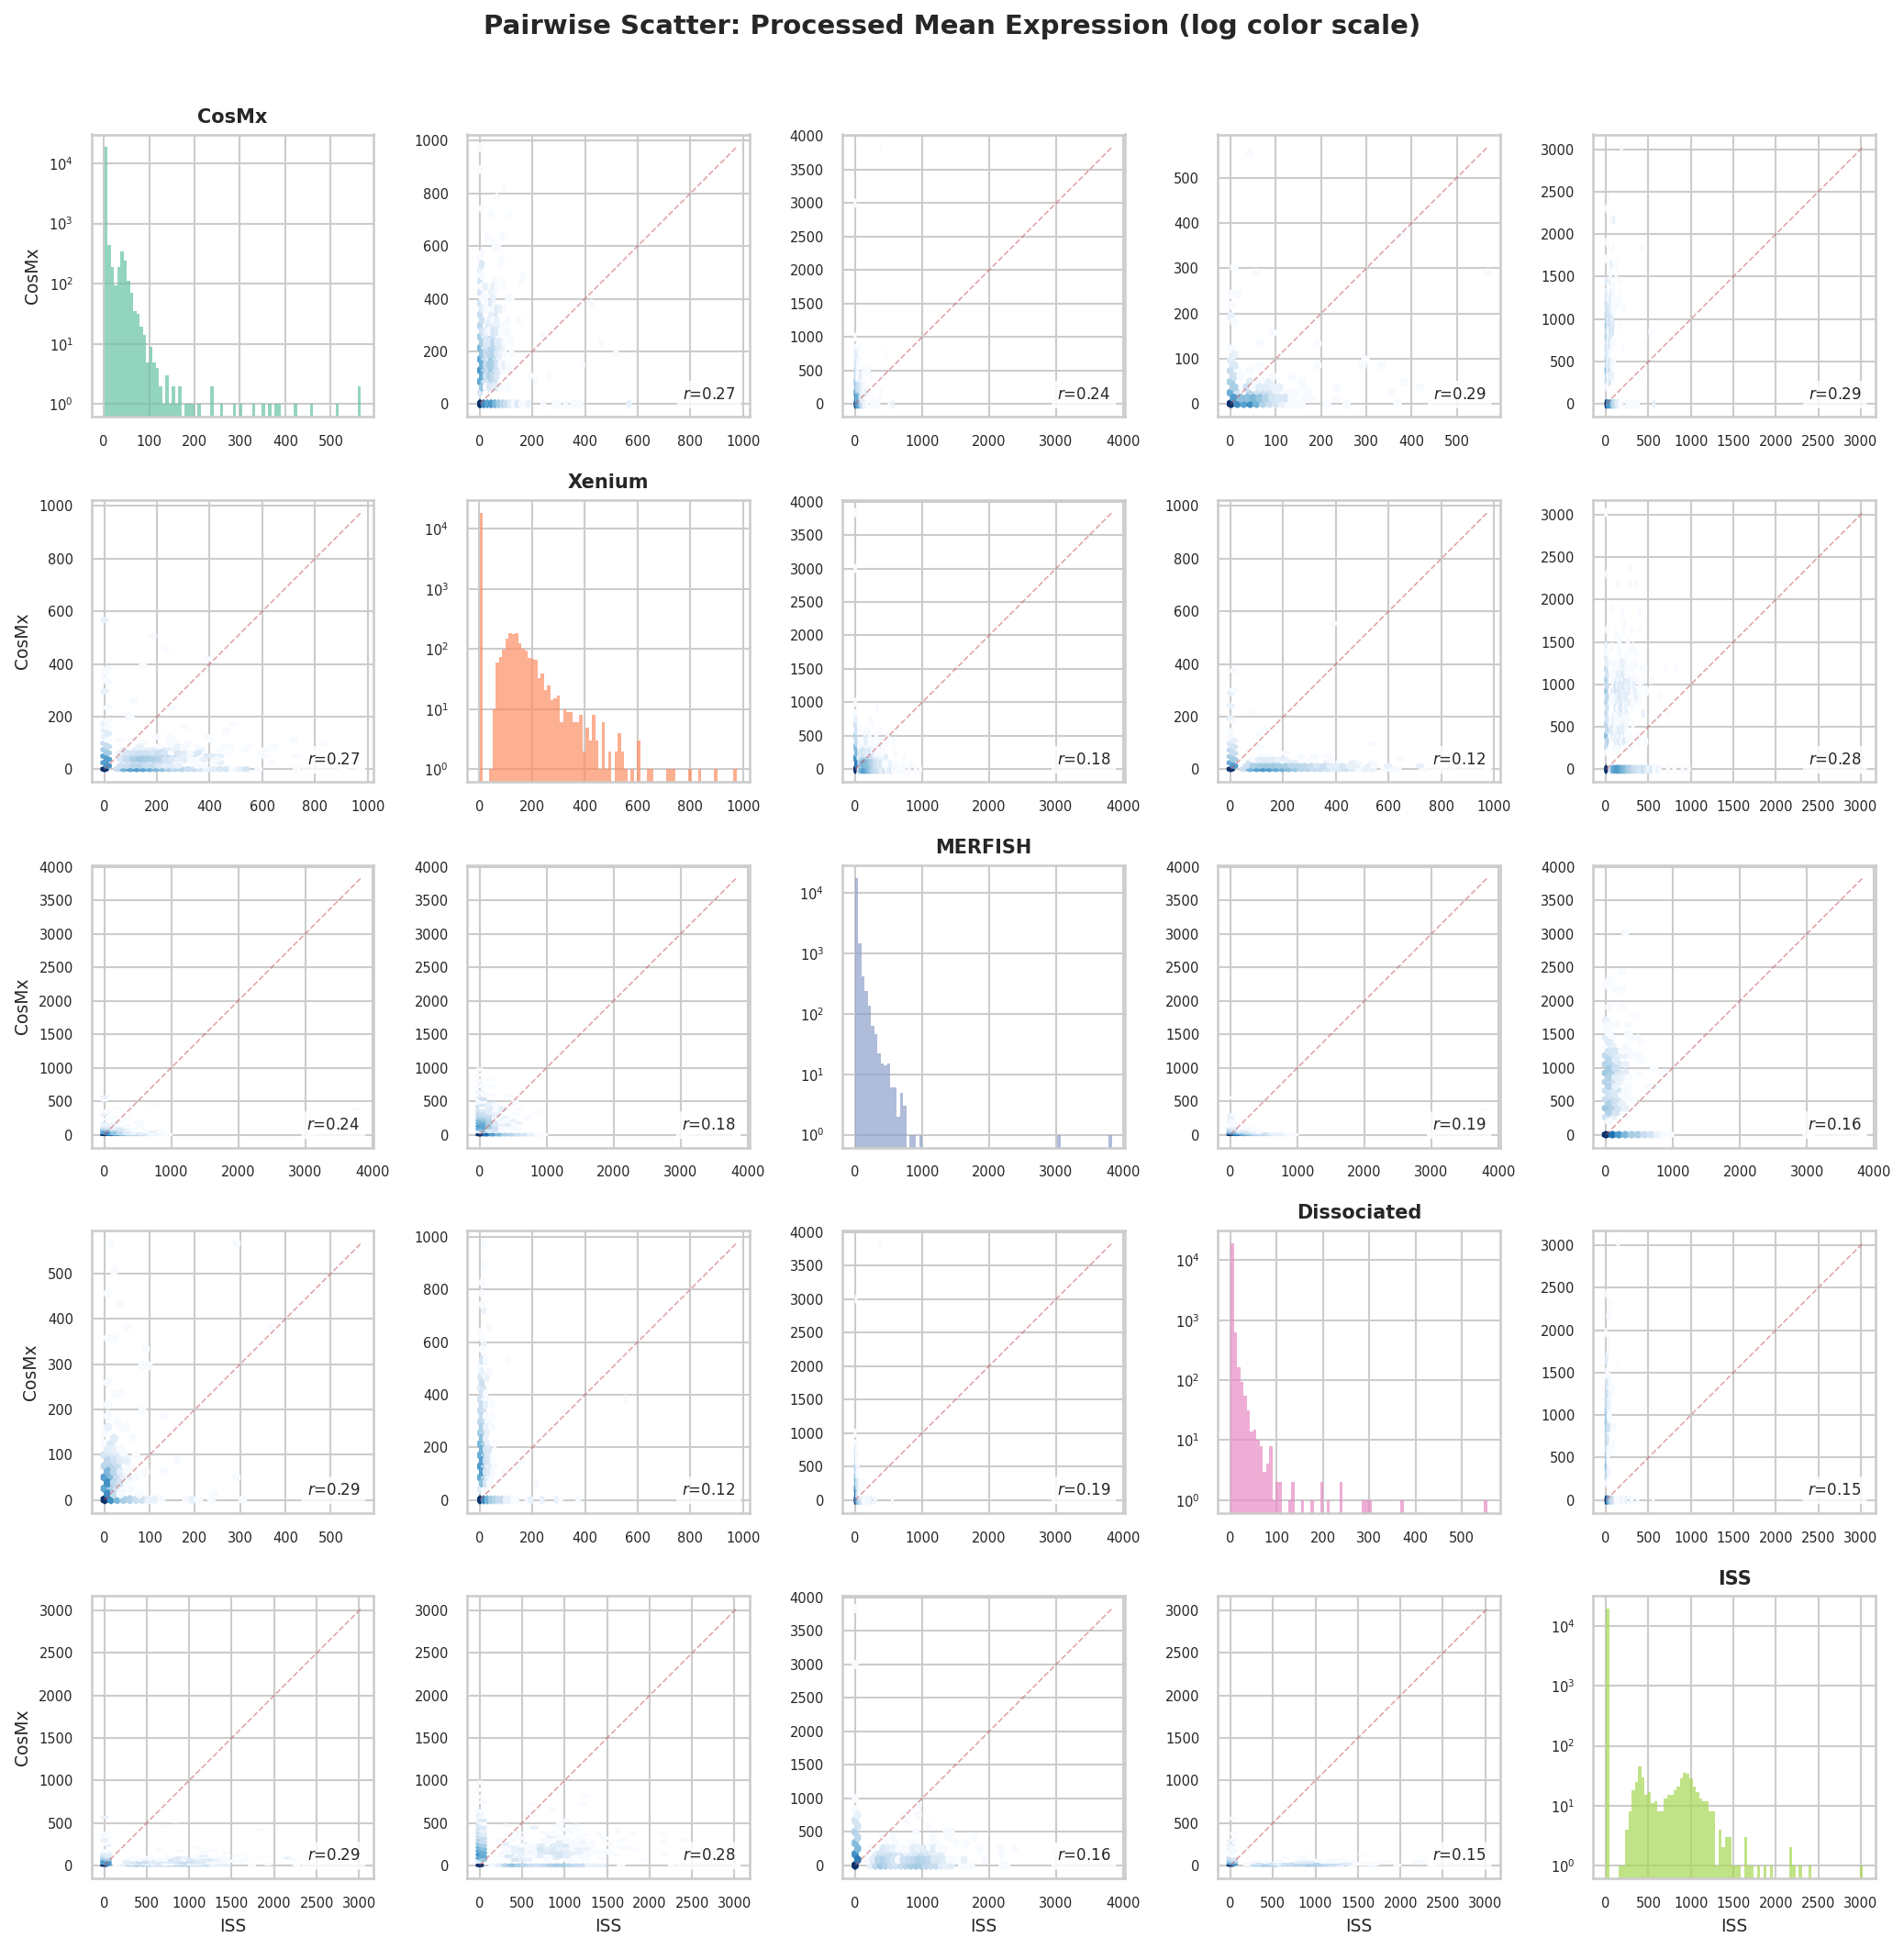

In [8]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i, t1 in enumerate(tech_names):
    for j, t2 in enumerate(tech_names):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogram
            vals = df_processed[t1][df_processed[t1] > 0]
            ax.hist(vals, bins=80, color=sns.color_palette('Set2')[i], alpha=0.7, edgecolor='none')
            ax.set_yscale('log')
            ax.set_title(t1, fontsize=10, fontweight='bold')
        else:
            # Off-diagonal: scatter
            mask = (df_processed[t1] > 0) & (df_processed[t2] > 0)
            x = df_processed[t1][mask]
            y = df_processed[t2][mask]
            
            # Use hexbin for dense plots
            hb = ax.hexbin(x, y, gridsize=40, cmap='Blues', mincnt=1, norm=LogNorm())
            
            # Add diagonal line
            max_val = max(x.max(), y.max())
            ax.plot([0, max_val], [0, max_val], 'r--', linewidth=0.8, alpha=0.5)
            
            # Add correlation annotation
            r, _ = pearsonr(x, y)
            ax.text(0.95, 0.05, f'$r$={r:.2f}', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        if j == 0:
            ax.set_ylabel(t2, fontsize=9)
        if i == n - 1:
            ax.set_xlabel(t1, fontsize=9)
        
        ax.tick_params(labelsize=7)

plt.suptitle('Pairwise Scatter: Processed Mean Expression (log color scale)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Top Expressed Genes Comparison

What are the most highly expressed genes in each technology?

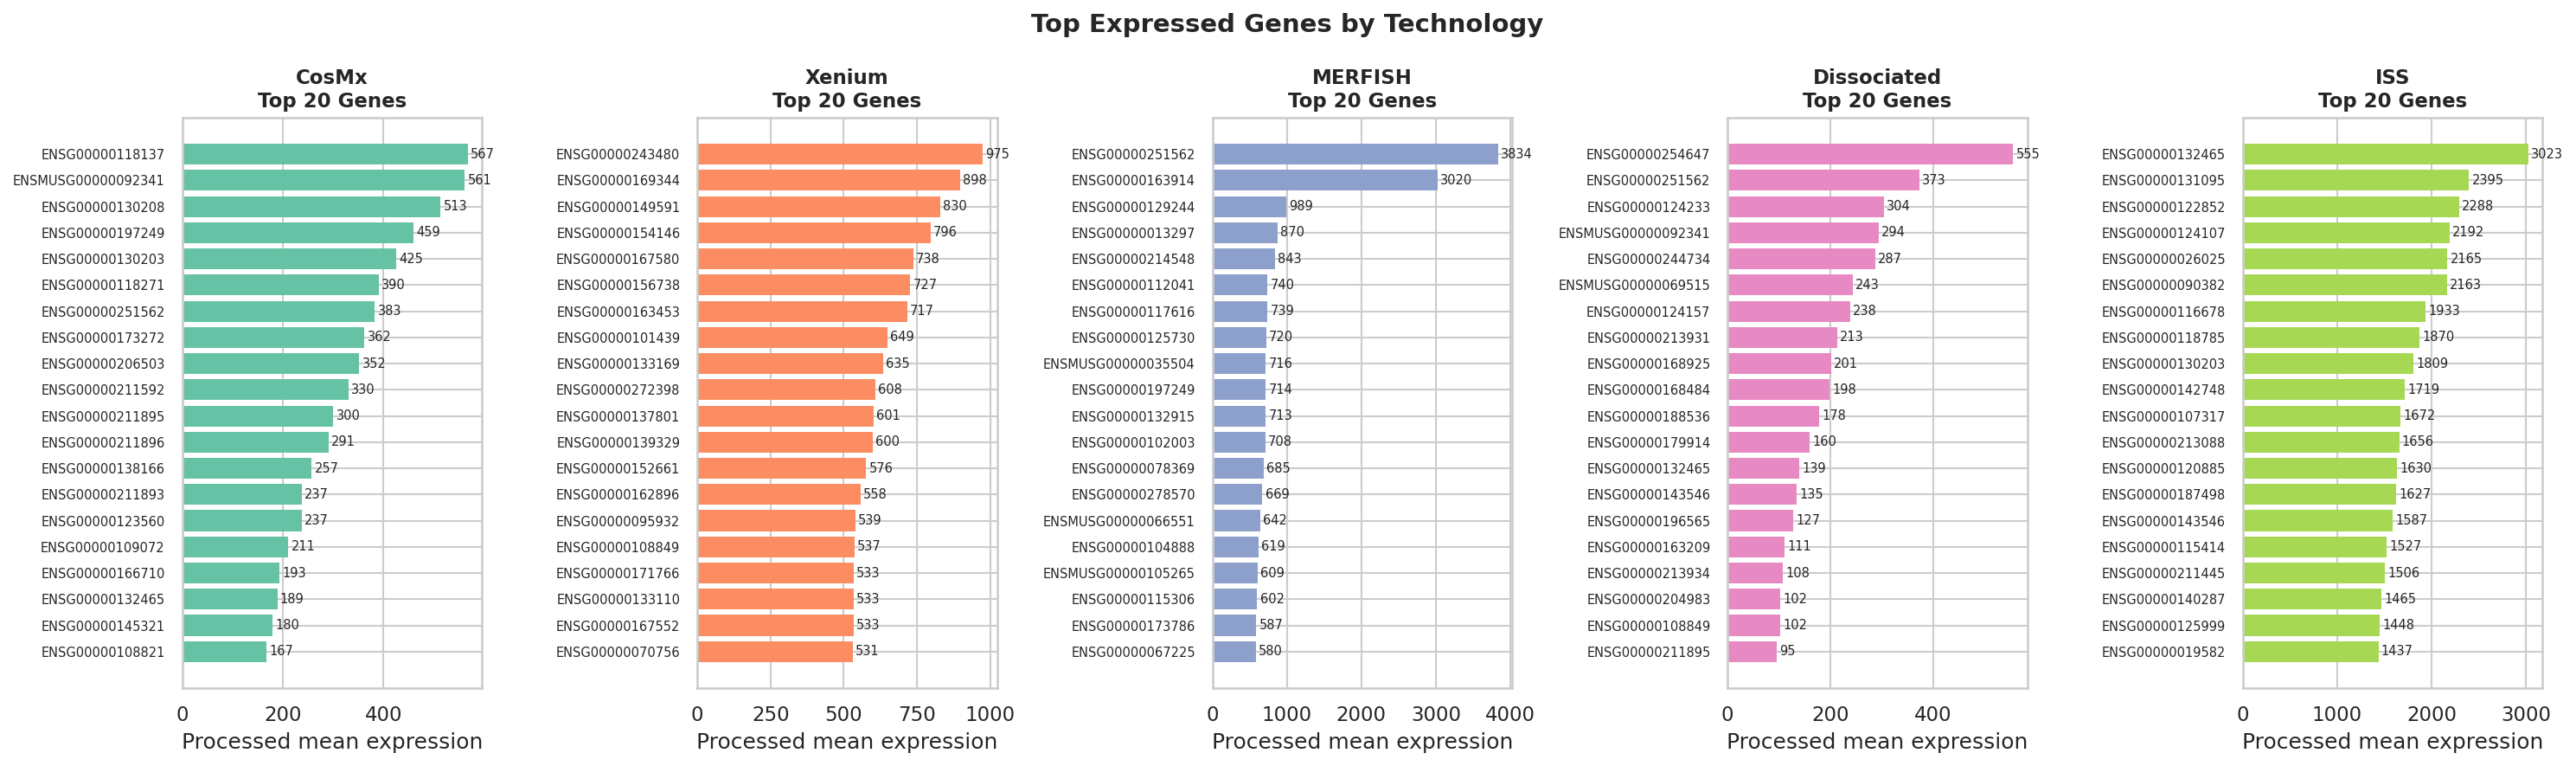

In [9]:
top_n = 20

fig, axes = plt.subplots(1, len(tech_names), figsize=(20, 6))

for i, (name, arr) in enumerate(processed.items()):
    ax = axes[i]
    # Get top N genes by mean expression
    top_idx = np.argsort(arr)[-top_n:][::-1]
    top_genes = [gene_names[idx] for idx in top_idx]
    top_vals = arr[top_idx]
    
    bars = ax.barh(range(top_n), top_vals, color=sns.color_palette('Set2')[i], edgecolor='none')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_genes, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{name}\nTop {top_n} Genes', fontsize=11, fontweight='bold')
    ax.set_xlabel('Processed mean expression')
    
    # Add value labels
    for bar, val in zip(bars, top_vals):
        ax.text(val + max(top_vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{int(val)}', va='center', fontsize=7)

plt.suptitle('Top Expressed Genes by Technology', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Shared Top Genes (Intersection Analysis)

How many of the top-N genes are shared between technologies?

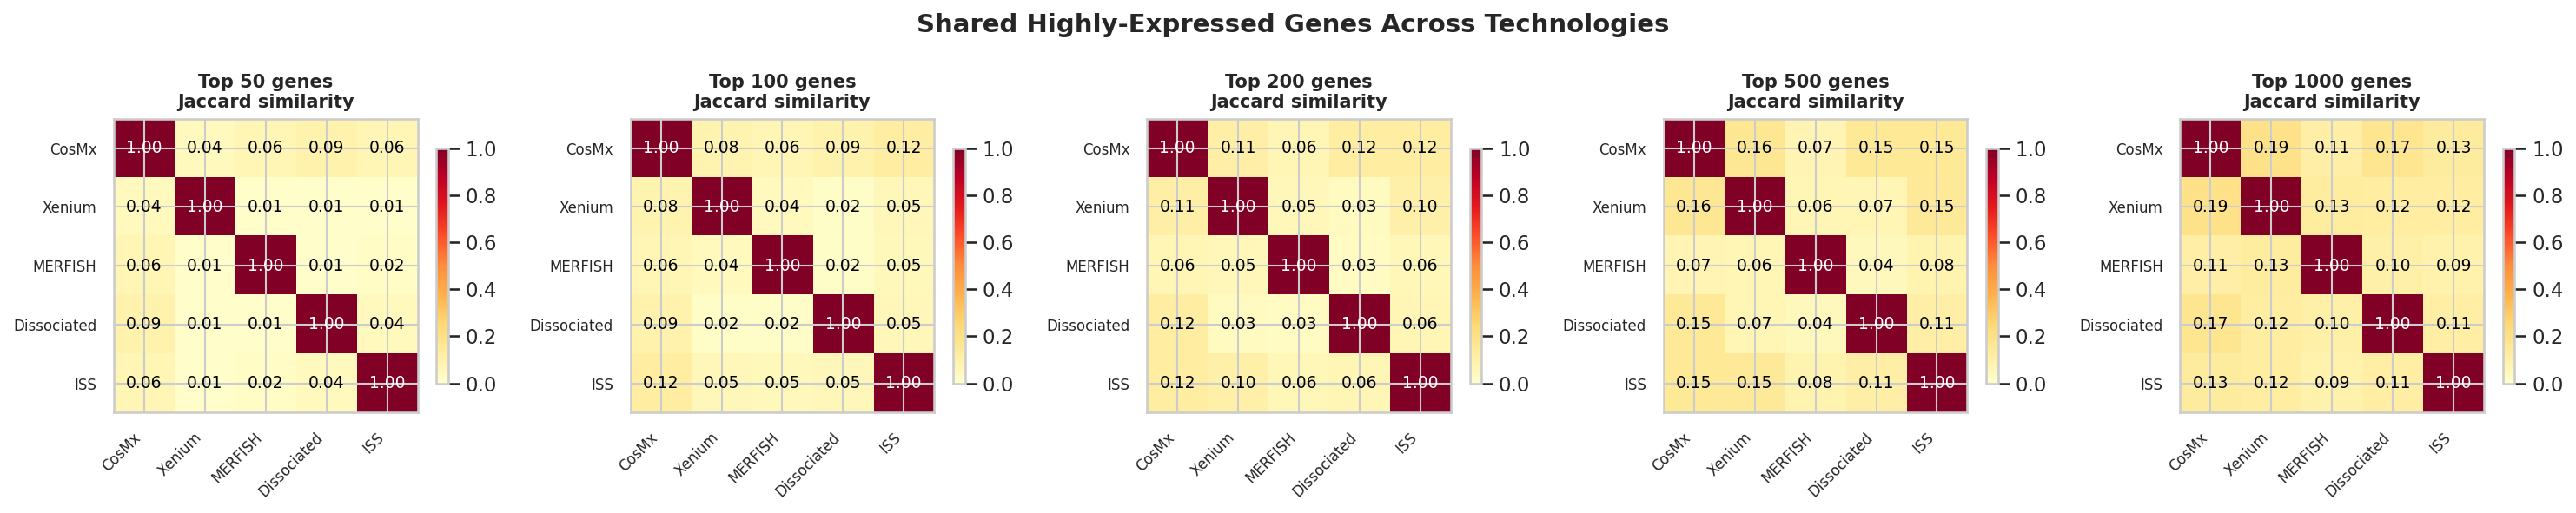

In [10]:
def top_genes_set(arr, n=100):
    """Return set of top N gene indices."""
    return set(np.argsort(arr)[-n:])

top_n_values = [50, 100, 200, 500, 1000]

fig, axes = plt.subplots(1, len(top_n_values), figsize=(20, 4))

for k, top_n in enumerate(top_n_values):
    ax = axes[k]
    
    # Compute pairwise Jaccard similarity
    jaccard = np.zeros((n, n))
    for i, t1 in enumerate(tech_names):
        for j, t2 in enumerate(tech_names):
            s1 = top_genes_set(processed[t1], top_n)
            s2 = top_genes_set(processed[t2], top_n)
            intersection = len(s1 & s2)
            union = len(s1 | s2)
            jaccard[i, j] = intersection / union if union > 0 else 0
    
    im = ax.imshow(jaccard, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{jaccard[i, j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if jaccard[i, j] > 0.5 else 'black')
    
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tech_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tech_names, fontsize=8)
    ax.set_title(f'Top {top_n} genes\nJaccard similarity', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Shared Highly-Expressed Genes Across Technologies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. PCA of Technology Mean Profiles

How do the technologies cluster based on their mean expression profiles?

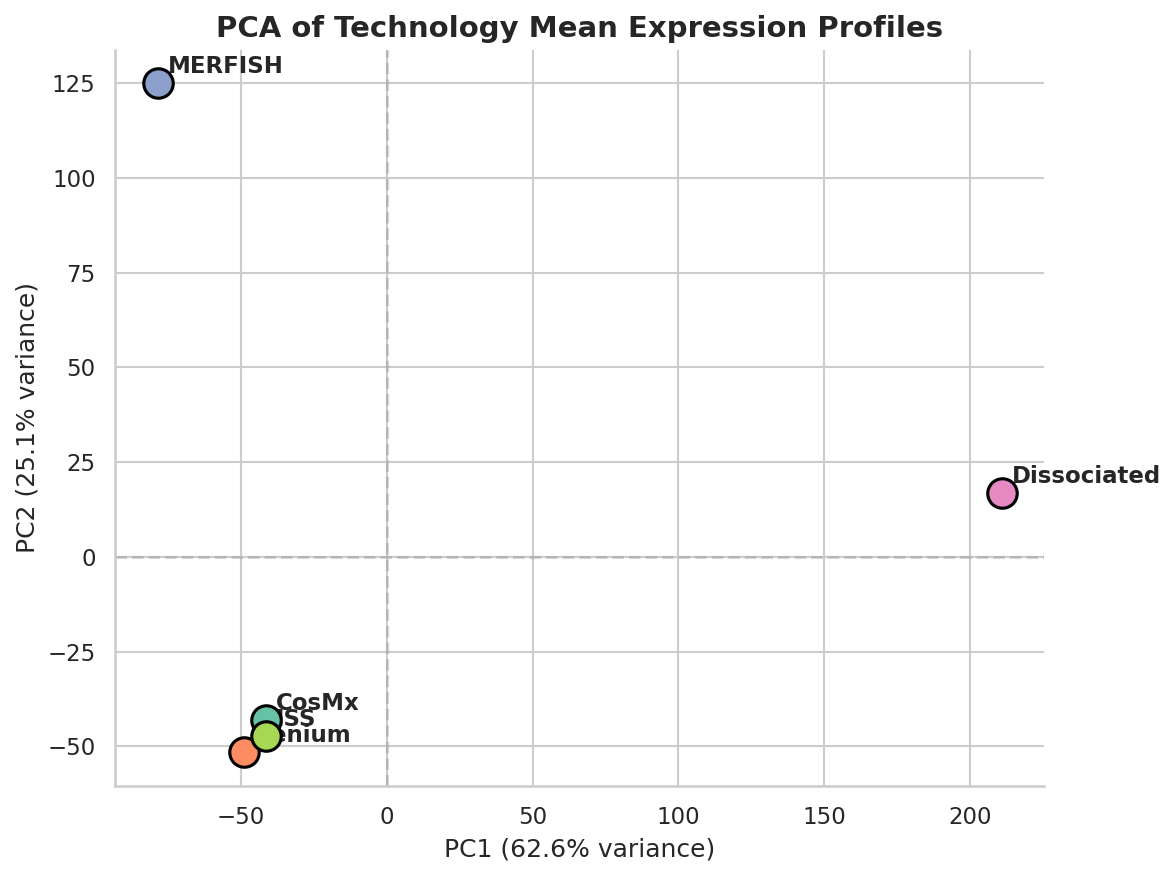

Explained variance ratio: PC1=62.6%, PC2=25.1%


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use processed means, transpose so genes are features, technologies are samples
X = df_processed.values.T  # shape: (5, 20310)

# Replace NaN with 0 for PCA
X_clean = np.nan_to_num(X)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette('Set2', n_colors=len(tech_names))

for i, name in enumerate(tech_names):
    ax.scatter(X_pca[i, 0], X_pca[i, 1], c=[colors[i]], s=200, edgecolors='black', linewidths=1.5, zorder=5)
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of Technology Mean Expression Profiles', fontsize=14, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

## 8. Summary Statistics Table

In [12]:
summary = []
for name, arr in means.items():
    processed_arr = process_mean(arr)
    n_genes = np.sum(processed_arr > 0)  # genes with actual expression (not NaN-replaced)
    n_nan = np.isnan(arr).sum()
    
    non_zero = processed_arr[processed_arr > 1]
    
    summary.append({
        'Technology': name,
        'Genes Detected': n_genes,
        'Coverage (%)': f'{n_genes / len(arr) * 100:.1f}%',
        'NaN Genes': n_nan,
        'Mean (processed)': f'{non_zero.mean():.1f}' if len(non_zero) > 0 else 'N/A',
        'Median (processed)': f'{np.median(non_zero):.1f}' if len(non_zero) > 0 else 'N/A',
        'Max (processed)': f'{processed_arr.max():.0f}',
        'Min (processed)': f'{processed_arr[processed_arr > 0].min():.0f}' if (processed_arr > 0).any() else 'N/A',
    })

summary_df = pd.DataFrame(summary)
summary_df

,Technology,Genes Detected,Coverage (%),NaN Genes,Mean (processed),Median (processed),Max (processed),Min (processed)
0,CosMx,20310,100.0%,18453,38.3,36.0,567,1
1,Xenium,20310,100.0%,18575,166.2,143.0,975,1
2,MERFISH,20262,99.8%,14505,69.0,43.0,3834,1
3,Dissociated,20288,99.9%,60,3.9,2.0,555,1
4,ISS,20310,100.0%,19776,800.1,844.0,3023,1


## 9. Raw (Unprocessed) Mean Distribution

Before processing, what do the raw values look like?

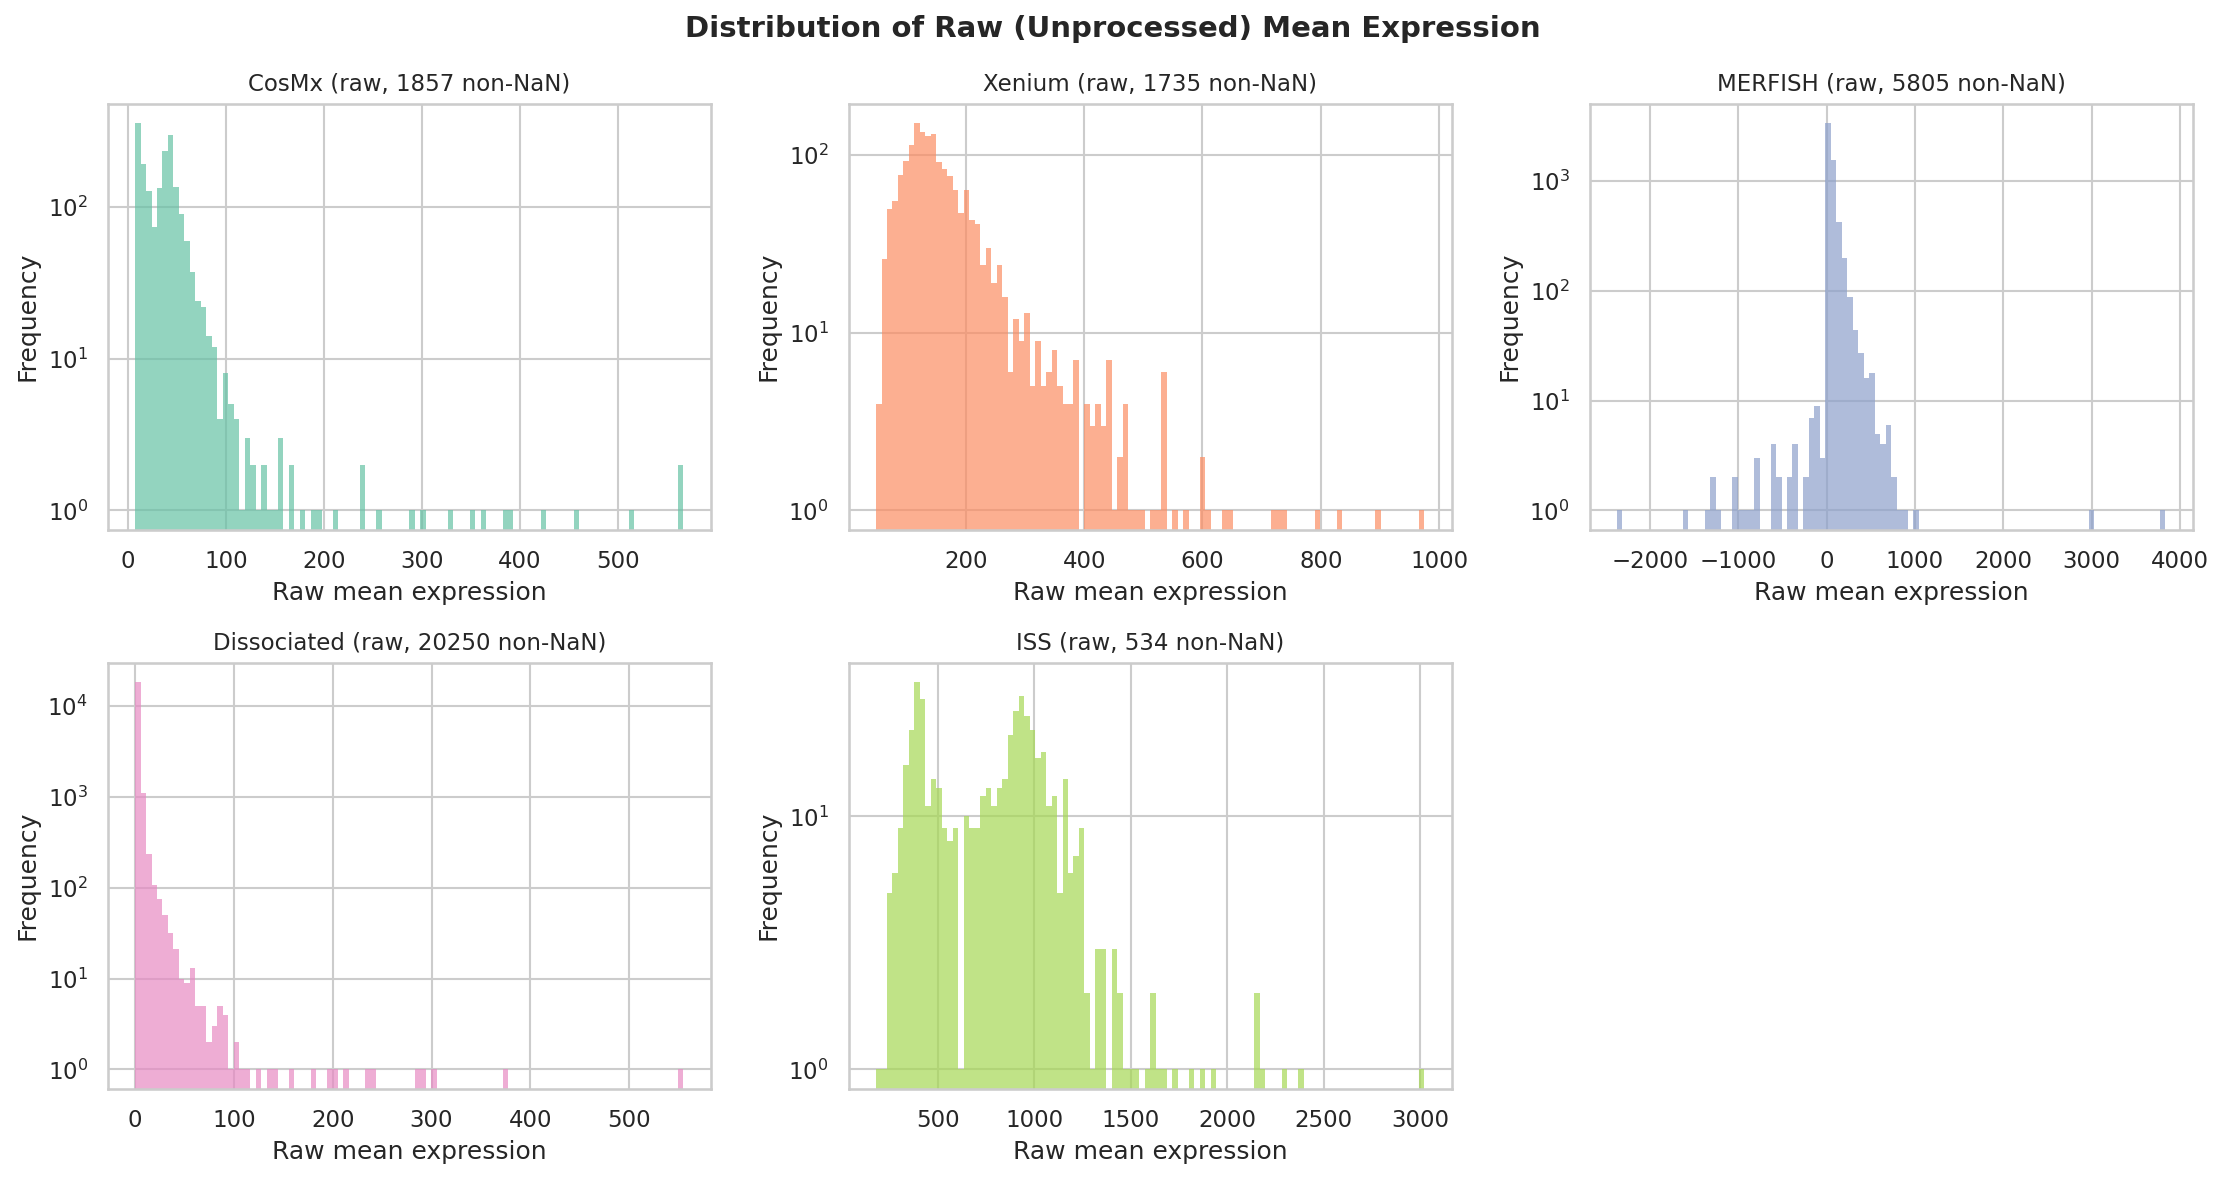

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, arr) in enumerate(means.items()):
    ax = axes[i]
    # Only show non-NaN values
    valid = arr[~np.isnan(arr)]
    ax.hist(valid, bins=100, color=sns.color_palette('Set2')[i], alpha=0.7, edgecolor='none')
    ax.set_title(f'{name} (raw, {len(valid)} non-NaN)', fontsize=11)
    ax.set_xlabel('Raw mean expression')
    ax.set_ylabel('Frequency')
    ax.set_yscale('log')

axes[5].set_visible(False)
plt.suptitle('Distribution of Raw (Unprocessed) Mean Expression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Effect of Processing (Before vs After)

How does the processing pipeline (nan_to_num → round → replace zeros with 1) change the distribution?

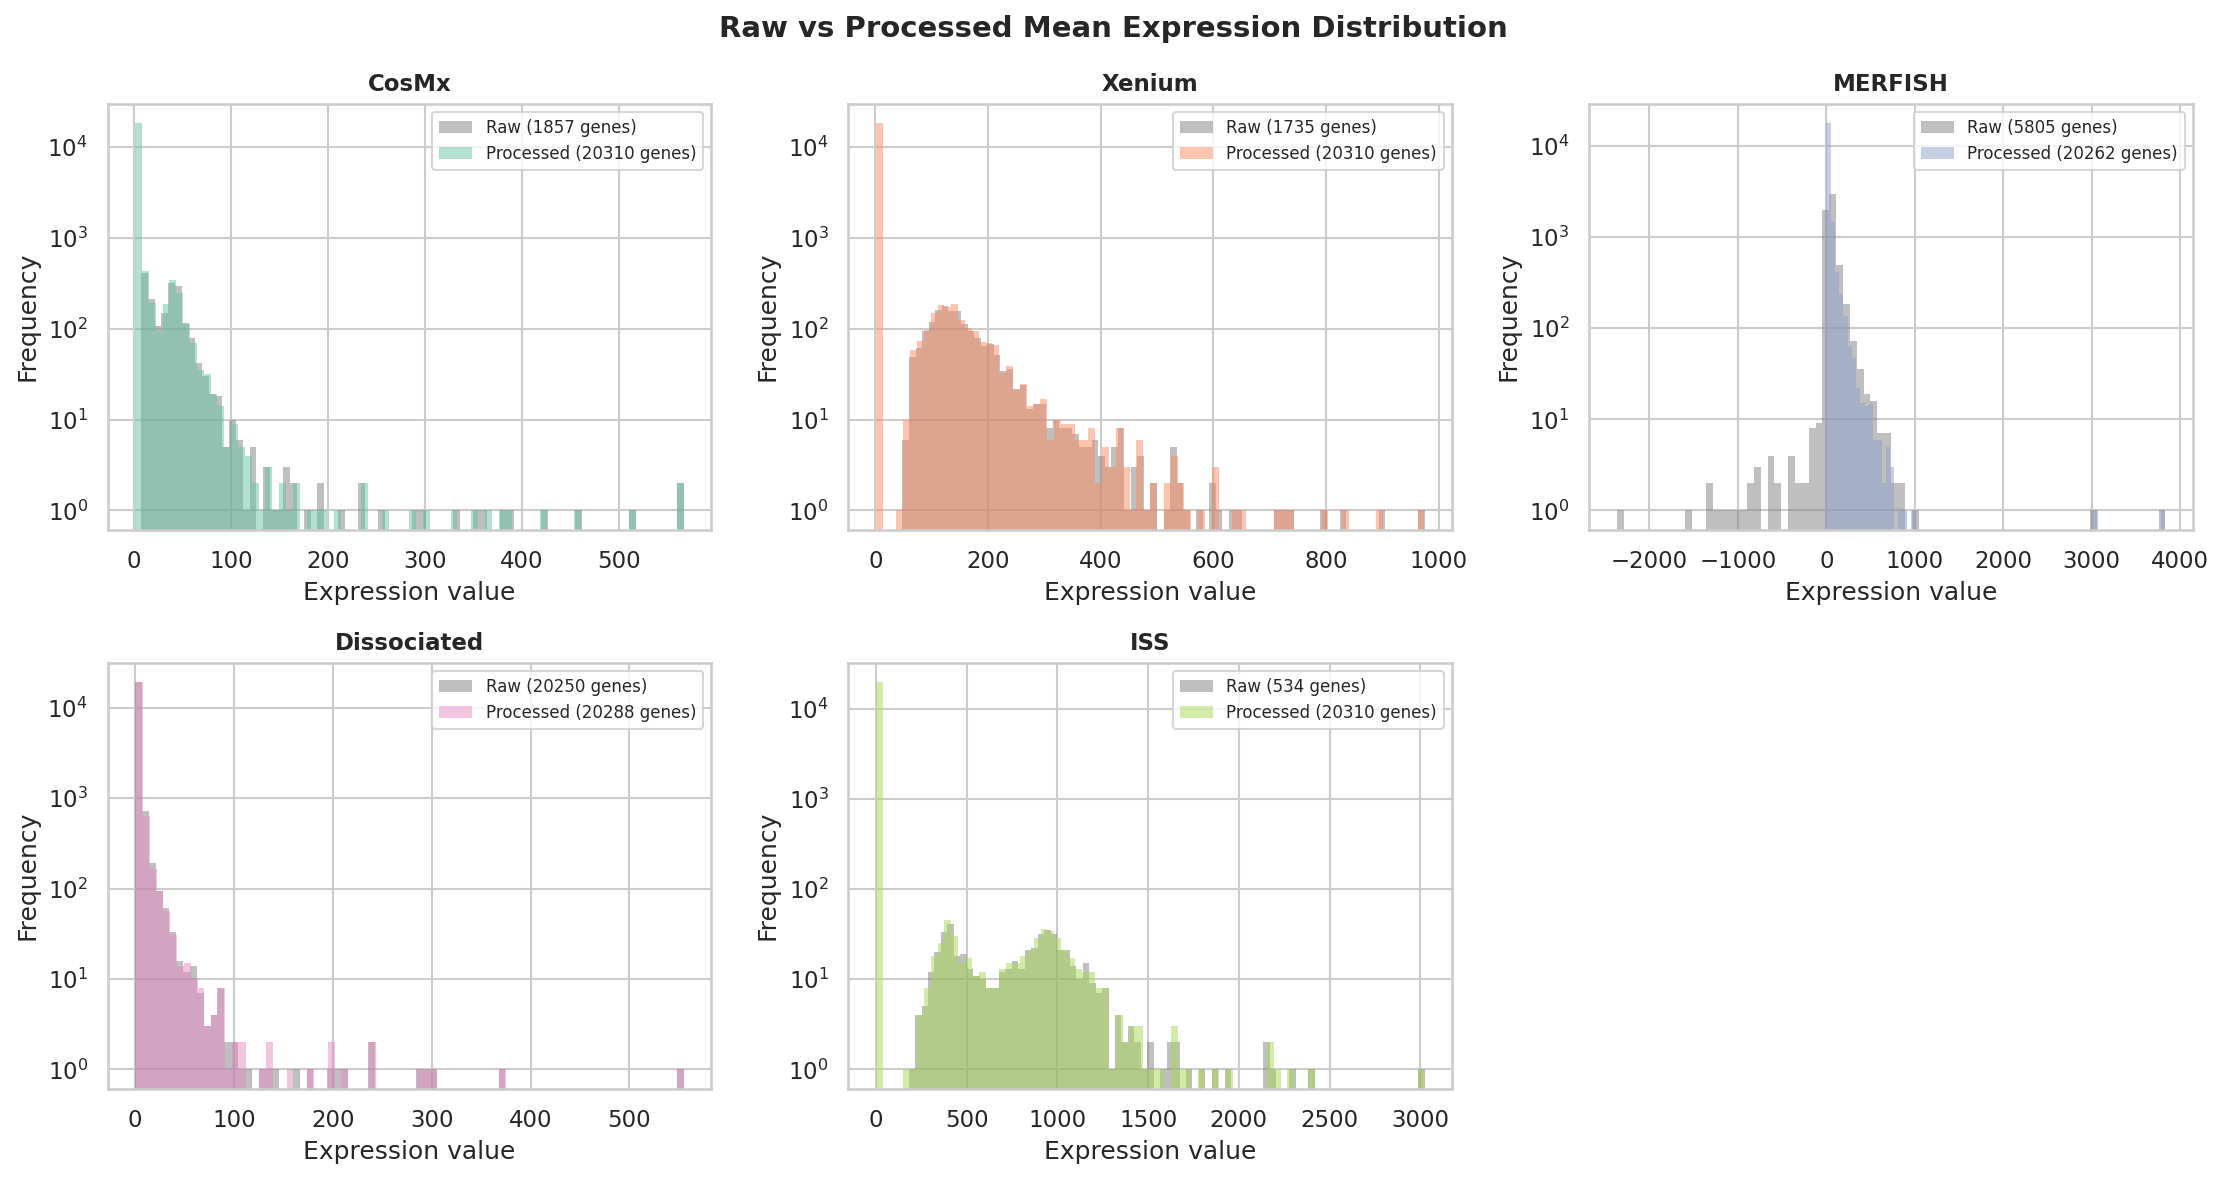

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, arr) in enumerate(means.items()):
    ax = axes[i]
    
    # Raw (non-NaN only)
    valid = arr[~np.isnan(arr)]
    ax.hist(valid, bins=80, alpha=0.5, label=f'Raw ({len(valid)} genes)', color='gray', edgecolor='none')
    
    # Processed (non-zero only)
    proc = process_mean(arr)
    non_zero = proc[proc > 0]
    ax.hist(non_zero, bins=80, alpha=0.5, label=f'Processed ({len(non_zero)} genes)', 
            color=sns.color_palette('Set2')[i], edgecolor='none')
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Expression value')
    ax.set_ylabel('Frequency')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Raw vs Processed Mean Expression Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Observations

1. **Gene Coverage**: Dissociated (scRNA-seq) has the highest gene coverage with the fewest NaNs, while ISS has the most NaNs (fewest detected genes).
2. **Expression Range**: Different technologies have different dynamic ranges for mean expression.
3. **Cross-Technology Correlation**: Spatial technologies (CosMx, Xenium, MERFISH) tend to correlate more with each other than with dissociated data.
4. **Processing Effect**: The `nan_to_num → round → replace zeros with 1` pipeline converts sparse NaN-filled vectors into dense integer vectors suitable for tokenization.